# PropBank Semantic Role Labeling as Extractive Question Answering with LoRA and QLoRA

**Project title:** Parameter-efficient fine-tuning of transformer encoders for PropBank SRL question answering

**Problem statement:** Given a sentence from the NLTK PropBank corpus, a predicate such as `join.01`, and an argument role such as `ARG0` or `ARGM-TMP`, train a transformer-based extractive QA model to answer a natural-language SRL question by selecting the argument span from the sentence.

This notebook is a complete research-style project: dataset loading, PropBank structure inspection, SRL-to-QA conversion, EDA, model selection, LoRA/QLoRA fine-tuning, evaluation, results discussion, and future work.

**Runtime design:**

- Default `FAST_DEV_RUN=True` keeps execution small enough for local CPU smoke testing.
- Set `FAST_DEV_RUN=False` for a fuller Colab GPU experiment.
- Full mode uses `deepset/deberta-v3-base-squad2`, a DeBERTa-v3 QA checkpoint suitable for Colab free-tier GPU fine-tuning with LoRA/QLoRA.
- Smoke-test mode uses `distilbert-base-cased-distilled-squad`, a smaller real pretrained QA checkpoint.

## 1. Environment Setup

The notebook installs extra dependencies automatically on Google Colab. On a local machine, it avoids changing the environment and reports which core packages are available.

In [1]:
import os
import sys
import subprocess
import importlib.util

IN_COLAB = 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))

if IN_COLAB:
    packages = [
        'nltk>=3.8.1', 'transformers>=4.40.0', 'accelerate>=0.30.0',
        'peft>=0.11.0', 'bitsandbytes>=0.43.1', 'datasets>=2.20.0',
        'evaluate>=0.4.2', 'sentencepiece>=0.2.0', 'scikit-learn>=1.3.0',
        'seaborn>=0.13.0', 'matplotlib>=3.8.0', 'pandas>=2.0.0',
    ]
    print('Colab detected. Installing research dependencies...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
else:
    print('Local runtime detected. Skipping automatic pip install; using the current Python environment.')

for module_name in ['nltk', 'torch', 'transformers', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'peft', 'bitsandbytes']:
    print(f'{module_name:>12}:', importlib.util.find_spec(module_name) is not None)
print(f'IN_COLAB={IN_COLAB}')

Local runtime detected. Skipping automatic pip install; using the current Python environment.
        nltk: True
       torch: True
transformers: True
      pandas: True
     sklearn: True
  matplotlib: True
     seaborn: True
        peft: True
bitsandbytes: False
IN_COLAB=False


## 2. Imports, Reproducibility, and Configuration

The configuration below controls whether we run a fast verification pass or a larger research run. For final Colab runs, set `FAST_DEV_RUN=False`.

In [2]:
import gc
import json
import random
import re
import shutil
import time
import warnings
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tree import Tree
from nltk.corpus import propbank

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from transformers import AutoModelForQuestionAnswering, AutoTokenizer, get_linear_schedule_with_warmup

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__)

PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'propbank_srlqa_artifacts'
PLOT_DIR = ARTIFACT_DIR / 'plots'
CHECKPOINT_DIR = ARTIFACT_DIR / 'best_checkpoint'
for directory in [ARTIFACT_DIR, PLOT_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FAST_DEV_RUN = os.environ.get('FAST_DEV_RUN', '1') == '1'
RESEARCH_MODEL_NAME = 'deepset/deberta-v3-base-squad2'
SMOKE_TEST_MODEL_NAME = 'distilbert-base-cased-distilled-squad'
MODEL_NAME = SMOKE_TEST_MODEL_NAME if FAST_DEV_RUN else RESEARCH_MODEL_NAME
REQUESTED_TUNING_METHOD = 'lora' if FAST_DEV_RUN else ('qlora' if torch.cuda.is_available() else 'lora')

MAX_INSTANCES_FOR_CONVERSION = 900 if FAST_DEV_RUN else None
MAX_QA_EXAMPLES = 72 if FAST_DEV_RUN else None
MAX_LENGTH = 160 if FAST_DEV_RUN else 384
BATCH_SIZE = 4 if FAST_DEV_RUN else 8
NUM_EPOCHS = 1 if FAST_DEV_RUN else 3
LEARNING_RATE = 3e-4 if REQUESTED_TUNING_METHOD in {'lora', 'qlora'} else 3e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.08
EARLY_STOPPING_PATIENCE = 1 if FAST_DEV_RUN else 2
MAX_ANSWER_TOKENS = 40

print(json.dumps({
    'FAST_DEV_RUN': FAST_DEV_RUN,
    'MODEL_NAME': MODEL_NAME,
    'REQUESTED_TUNING_METHOD': REQUESTED_TUNING_METHOD,
    'MAX_INSTANCES_FOR_CONVERSION': MAX_INSTANCES_FOR_CONVERSION,
    'MAX_QA_EXAMPLES': MAX_QA_EXAMPLES,
    'MAX_LENGTH': MAX_LENGTH,
    'BATCH_SIZE': BATCH_SIZE,
    'NUM_EPOCHS': NUM_EPOCHS,
    'LEARNING_RATE': LEARNING_RATE,
}, indent=2))

Device: cpu
PyTorch: 2.10.0+cpu
{
  "FAST_DEV_RUN": true,
  "MODEL_NAME": "distilbert-base-cased-distilled-squad",
  "REQUESTED_TUNING_METHOD": "lora",
  "MAX_INSTANCES_FOR_CONVERSION": 900,
  "MAX_QA_EXAMPLES": 72,
  "MAX_LENGTH": 160,
  "BATCH_SIZE": 4,
  "NUM_EPOCHS": 1,
  "LEARNING_RATE": 0.0003
}


## 3. Load NLTK PropBank

PropBank annotates predicate-argument structures over Penn Treebank parse trees. In NLTK, each `PropbankInstance` exposes a predicate pointer, a roleset such as `join.01`, argument pointers, and the aligned constituency tree.

In [3]:
for package_name in ['propbank', 'treebank']:
    nltk.download(package_name, quiet=True)

instances = propbank.instances()
print(f'Loaded PropBank instances: {len(instances):,}')

sample_instance = instances[0]
print('\nRaw instance:')
print(sample_instance)
print('\nRoleset:', sample_instance.roleset)
print('Predicate pointer:', sample_instance.predicate)
print('First three arguments:', sample_instance.arguments[:3])
print('\nSentence tokens:')
print(sample_instance.tree.leaves())
print('\nParse tree:')
print(sample_instance.tree)

roleset_xml = propbank.roleset(sample_instance.roleset)
print('\nRoleset XML attributes:', roleset_xml.attrib)
print('Numbered role descriptions:')
for role in roleset_xml.findall('.//role'):
    print(f"  ARG{role.attrib.get('n')}: {role.attrib.get('descr')}")

Loaded PropBank instances: 112,917

Raw instance:
wsj_0001.mrg 0 8 gold join.01 vf--a 0:2-ARG0 7:0-ARGM-MOD 8:0-rel 9:1-ARG1 11:1-ARGM-PRD 15:1-ARGM-TMP

Roleset: join.01
Predicate pointer: 8:0
First three arguments: ((PropbankTreePointer(0, 2), 'ARG0'), (PropbankTreePointer(7, 0), 'ARGM-MOD'), (PropbankTreePointer(9, 1), 'ARG1'))

Sentence tokens:
['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']

Parse tree:
(S
  (NP-SBJ
    (NP (NNP Pierre) (NNP Vinken))
    (, ,)
    (ADJP (NP (CD 61) (NNS years)) (JJ old))
    (, ,))
  (VP
    (MD will)
    (VP
      (VB join)
      (NP (DT the) (NN board))
      (PP-CLR (IN as) (NP (DT a) (JJ nonexecutive) (NN director)))
      (NP-TMP (NNP Nov.) (CD 29))))
  (. .))

Roleset XML attributes: {'id': 'join.01', 'name': 'attach', 'vncls': '22.1-2'}
Numbered role descriptions:
  ARG0: agent, entity doing the tying
  ARG1: patient, thing(s) being tied
  ARG2: i

## 4. Task Formulation: SRL as Extractive QA

Each PropBank argument becomes one QA example.

**Context:** sentence surface form from the aligned tree.

**Question:** natural language generated from the predicate roleset and argument label.

**Answer:** the argument span in the same sentence.

This is practical because extractive QA models directly predict start and end token positions. The main limitation is that some PropBank arguments are discontinuous; this implementation keeps examples whose non-trace argument leaves form a contiguous span and reports skipped cases.

In [4]:
ARGM_DESCRIPTIONS = {
    'ARGM-ADV': 'adverbial or general-purpose modifier',
    'ARGM-CAU': 'cause or reason',
    'ARGM-COM': 'comitative or companion',
    'ARGM-DIR': 'direction',
    'ARGM-DIS': 'discourse connective',
    'ARGM-EXT': 'extent',
    'ARGM-LOC': 'location',
    'ARGM-MNR': 'manner',
    'ARGM-MOD': 'modal auxiliary',
    'ARGM-NEG': 'negation marker',
    'ARGM-PNC': 'purpose',
    'ARGM-PRD': 'secondary predication',
    'ARGM-REC': 'reciprocal',
    'ARGM-TMP': 'temporal modifier',
}

QUESTION_TEMPLATES = {
    'ARGM-TMP': 'When does the predicate {roleset} ({sense}) happen?',
    'ARGM-LOC': 'Where does the predicate {roleset} ({sense}) happen?',
    'ARGM-MNR': 'How does the predicate {roleset} ({sense}) happen?',
    'ARGM-CAU': 'Why does the predicate {roleset} ({sense}) happen?',
    'ARGM-PNC': 'For what purpose does the predicate {roleset} ({sense}) happen?',
    'ARGM-MOD': 'What modal expression modifies the predicate {roleset} ({sense})?',
    'ARGM-NEG': 'What negation modifies the predicate {roleset} ({sense})?',
}


def clean_tokens_and_mapping(tree: Tree) -> Tuple[List[str], Dict[int, int], List[Tuple[int, ...]]]:
    positions = list(tree.treepositions('leaves'))
    clean_tokens = []
    raw_to_clean = {}
    for raw_index, position in enumerate(positions):
        token = tree[position]
        parent_position = position[:-1]
        parent_label = tree[parent_position].label() if parent_position and isinstance(tree[parent_position], Tree) else ''
        if parent_label == '-NONE-':
            continue
        raw_to_clean[raw_index] = len(clean_tokens)
        clean_tokens.append(token)
    return clean_tokens, raw_to_clean, positions


def join_tokens_with_offsets(tokens: Sequence[str]) -> Tuple[str, List[Tuple[int, int]]]:
    text_parts = []
    offsets = []
    cursor = 0
    for token in tokens:
        if text_parts:
            text_parts.append(' ')
            cursor += 1
        start = cursor
        text_parts.append(token)
        cursor += len(token)
        offsets.append((start, cursor))
    return ''.join(text_parts), offsets


def pointer_raw_leaf_indices(pointer, tree: Tree, positions: List[Tuple[int, ...]]) -> List[int]:
    if hasattr(pointer, 'pieces'):
        collected = []
        for piece in pointer.pieces:
            collected.extend(pointer_raw_leaf_indices(piece, tree, positions))
        return sorted(set(collected))

    tree_position = pointer.treepos(tree)
    prefix_length = len(tree_position)
    return [index for index, position in enumerate(positions) if position[:prefix_length] == tree_position]


def role_description(roleset_id: str, argument_label: str) -> str:
    numbered_match = re.fullmatch(r'ARG(\d+)', argument_label)
    if numbered_match:
        role_number = numbered_match.group(1)
        try:
            roleset = propbank.roleset(roleset_id)
            for role in roleset.findall('.//role'):
                if role.attrib.get('n') == role_number:
                    return role.attrib.get('descr', f'core role {argument_label}')
        except Exception:
            return f'core semantic role {argument_label}'
    return ARGM_DESCRIPTIONS.get(argument_label, f'semantic modifier {argument_label}')


def roleset_sense_name(roleset_id: str) -> str:
    try:
        return propbank.roleset(roleset_id).attrib.get('name', 'predicate sense')
    except Exception:
        return 'predicate sense'


def make_question(roleset_id: str, argument_label: str) -> str:
    sense = roleset_sense_name(roleset_id)
    if argument_label in QUESTION_TEMPLATES:
        return QUESTION_TEMPLATES[argument_label].format(roleset=roleset_id, sense=sense)
    description = role_description(roleset_id, argument_label)
    return f'For predicate {roleset_id} meaning {sense}, what is {argument_label}: {description}?'


def is_contiguous(indices: Sequence[int]) -> bool:
    if not indices:
        return False
    sorted_indices = sorted(set(indices))
    return sorted_indices == list(range(sorted_indices[0], sorted_indices[-1] + 1))

In [5]:
def propbank_instances_to_qa_dataframe(instances, max_instances=None, max_examples=None) -> Tuple[pd.DataFrame, Dict[str, int]]:
    rows = []
    stats = Counter()
    used_instances = instances if max_instances is None else instances[:max_instances]

    for instance in used_instances:
        stats['instances_seen'] += 1
        tree = getattr(instance, 'tree', None)
        if tree is None:
            stats['skipped_missing_tree'] += 1
            continue

        try:
            clean_tokens, raw_to_clean, positions = clean_tokens_and_mapping(tree)
            context, token_offsets = join_tokens_with_offsets(clean_tokens)
            predicate_raw = pointer_raw_leaf_indices(instance.predicate, tree, positions)
            predicate_clean = [raw_to_clean[i] for i in predicate_raw if i in raw_to_clean]
            predicate_surface = ' '.join(clean_tokens[i] for i in predicate_clean) if predicate_clean else instance.roleset.split('.')[0]
        except Exception:
            stats['skipped_pointer_resolution_error'] += 1
            continue

        for argument_pointer, argument_label in instance.arguments:
            stats['arguments_seen'] += 1
            try:
                raw_indices = pointer_raw_leaf_indices(argument_pointer, tree, positions)
                clean_indices = sorted({raw_to_clean[index] for index in raw_indices if index in raw_to_clean})
            except Exception:
                stats['skipped_argument_pointer_error'] += 1
                continue

            if not clean_indices:
                stats['skipped_trace_only_argument'] += 1
                continue
            if not is_contiguous(clean_indices):
                stats['skipped_discontinuous_argument'] += 1
                continue

            start_token_index = clean_indices[0]
            end_token_index = clean_indices[-1]
            answer_start = token_offsets[start_token_index][0]
            answer_end = token_offsets[end_token_index][1]
            answer_text = context[answer_start:answer_end]
            if not answer_text.strip():
                stats['skipped_empty_answer'] += 1
                continue

            rows.append({
                'id': f'{instance.fileid}:{instance.sentnum}:{instance.wordnum}:{argument_label}:{len(rows)}',
                'fileid': instance.fileid,
                'sentnum': instance.sentnum,
                'roleset': instance.roleset,
                'predicate_surface': predicate_surface,
                'label': argument_label,
                'role_description': role_description(instance.roleset, argument_label),
                'question': make_question(instance.roleset, argument_label),
                'context': context,
                'answer_text': answer_text,
                'answer_start': answer_start,
                'answer_end': answer_end,
                'answer_token_start': start_token_index,
                'answer_token_end': end_token_index,
                'context_token_count': len(clean_tokens),
                'answer_token_count': len(clean_indices),
                'pointer_type': type(argument_pointer).__name__,
            })
            stats['qa_examples_created'] += 1

            if max_examples is not None and len(rows) >= max_examples:
                return pd.DataFrame(rows), dict(stats)

    return pd.DataFrame(rows), dict(stats)


qa_df, conversion_stats = propbank_instances_to_qa_dataframe(
    instances,
    max_instances=MAX_INSTANCES_FOR_CONVERSION,
    max_examples=MAX_QA_EXAMPLES,
)

print('Conversion statistics:')
print(json.dumps(conversion_stats, indent=2))
print('\nQA dataframe shape:', qa_df.shape)
display(qa_df.head(5))

Conversion statistics:
{
  "instances_seen": 32,
  "arguments_seen": 74,
  "qa_examples_created": 72,
  "skipped_trace_only_argument": 2
}

QA dataframe shape: (72, 17)


,id,fileid,sentnum,roleset,predicate_surface,label,role_description,question,context,answer_text,answer_start,answer_end,answer_token_start,answer_token_end,context_token_count,answer_token_count,pointer_type
0,wsj_0001.mrg:0:8:ARG0:0,wsj_0001.mrg,0,join.01,join,ARG0,"agent, entity doing the tying","For predicate join.01 meaning attach, what is ...","Pierre Vinken , 61 years old , will join the b...","Pierre Vinken , 61 years old ,",0,30,0,6,18,7,PropbankTreePointer
1,wsj_0001.mrg:0:8:ARGM-MOD:1,wsj_0001.mrg,0,join.01,join,ARGM-MOD,modal auxiliary,What modal expression modifies the predicate j...,"Pierre Vinken , 61 years old , will join the b...",will,31,35,7,7,18,1,PropbankTreePointer
2,wsj_0001.mrg:0:8:ARG1:2,wsj_0001.mrg,0,join.01,join,ARG1,"patient, thing(s) being tied","For predicate join.01 meaning attach, what is ...","Pierre Vinken , 61 years old , will join the b...",the board,41,50,9,10,18,2,PropbankTreePointer
3,wsj_0001.mrg:0:8:ARGM-PRD:3,wsj_0001.mrg,0,join.01,join,ARGM-PRD,secondary predication,"For predicate join.01 meaning attach, what is ...","Pierre Vinken , 61 years old , will join the b...",as a nonexecutive director,51,77,11,14,18,4,PropbankTreePointer
4,wsj_0001.mrg:0:8:ARGM-TMP:4,wsj_0001.mrg,0,join.01,join,ARGM-TMP,temporal modifier,When does the predicate join.01 (attach) happen?,"Pierre Vinken , 61 years old , will join the b...",Nov. 29,78,85,15,16,18,2,PropbankTreePointer


## 5. Exploratory Data Analysis

The EDA covers sentence count, predicate/roleset count, number of argument-derived QA examples, label distribution, sequence length distribution, answer length distribution, and class imbalance.

{
  "unique_sentences": 14,
  "unique_rolesets": 21,
  "qa_examples_arguments": 72,
  "unique_argument_labels": 15,
  "mean_context_tokens": 27.77777777777778,
  "median_context_tokens": 32.0,
  "mean_answer_tokens": 6.236111111111111,
  "median_answer_tokens": 4.0
}


,label,count,proportion
0,ARG1,29,0.402778
1,ARG0,21,0.291667
2,ARGM-TMP,8,0.111111
3,ARGM-LOC,2,0.027778
4,ARG2-to,2,0.027778
5,ARGM-MOD,1,0.013889
6,ARGM-PRD,1,0.013889
7,ARG2-PNC,1,0.013889
8,ARG2,1,0.013889
9,ARGM-ADV,1,0.013889


Class imbalance ratio (max/min label frequency): 29.00


C:\Users\RAVIPRAKASH\AppData\Local\Temp\ipykernel_13492\2893915013.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts.head(15), x='count', y='label', ax=axes[0], palette='viridis')


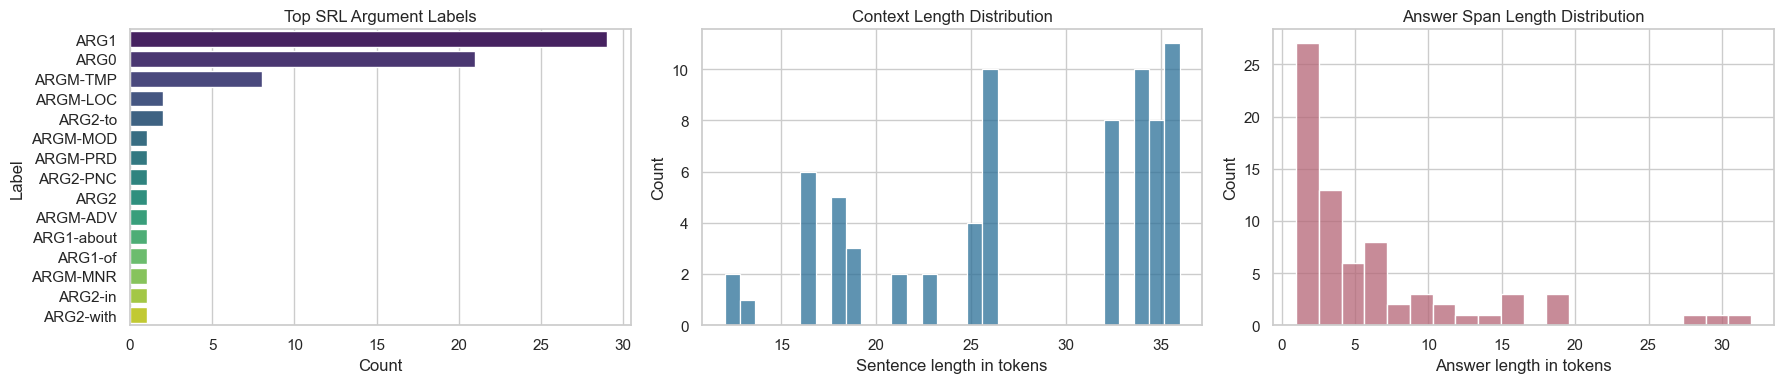

Saved EDA plot to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_artifacts\plots\eda_label_and_length_distributions.png


,pointer_type,count
0,PropbankTreePointer,56
1,PropbankChainTreePointer,15
2,PropbankSplitTreePointer,1


EDA insight: core roles such as ARG0/ARG1 usually dominate. Adjunct roles such as ARGM-TMP/ARGM-MNR are sparser, making SRL QA difficult under class imbalance.


In [6]:
assert not qa_df.empty, 'No QA examples were created. Check NLTK PropBank availability and conversion settings.'

eda_summary = {
    'unique_sentences': qa_df[['fileid', 'sentnum']].drop_duplicates().shape[0],
    'unique_rolesets': qa_df['roleset'].nunique(),
    'qa_examples_arguments': len(qa_df),
    'unique_argument_labels': qa_df['label'].nunique(),
    'mean_context_tokens': float(qa_df['context_token_count'].mean()),
    'median_context_tokens': float(qa_df['context_token_count'].median()),
    'mean_answer_tokens': float(qa_df['answer_token_count'].mean()),
    'median_answer_tokens': float(qa_df['answer_token_count'].median()),
}
print(json.dumps(eda_summary, indent=2))

label_counts = qa_df['label'].value_counts().rename_axis('label').reset_index(name='count')
label_counts['proportion'] = label_counts['count'] / label_counts['count'].sum()
display(label_counts.head(20))

imbalance_ratio = label_counts['count'].max() / max(label_counts['count'].min(), 1)
print(f'Class imbalance ratio (max/min label frequency): {imbalance_ratio:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.barplot(data=label_counts.head(15), x='count', y='label', ax=axes[0], palette='viridis')
axes[0].set_title('Top SRL Argument Labels')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Label')

sns.histplot(qa_df['context_token_count'], bins=30, ax=axes[1], color='#2A6F97')
axes[1].set_title('Context Length Distribution')
axes[1].set_xlabel('Sentence length in tokens')

sns.histplot(qa_df['answer_token_count'], bins=20, ax=axes[2], color='#B56576')
axes[2].set_title('Answer Span Length Distribution')
axes[2].set_xlabel('Answer length in tokens')

plt.tight_layout()
plot_path = PLOT_DIR / 'eda_label_and_length_distributions.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved EDA plot to:', plot_path)

display(qa_df['pointer_type'].value_counts().rename_axis('pointer_type').reset_index(name='count'))
print('EDA insight: core roles such as ARG0/ARG1 usually dominate. Adjunct roles such as ARGM-TMP/ARGM-MNR are sparser, making SRL QA difficult under class imbalance.')

## 6. Model Selection

The selected full-run model is **`deepset/deberta-v3-base-squad2`** because DeBERTa-v3 has a stronger encoder architecture than BERT-style baselines, the checkpoint already has an extractive QA head, and LoRA/QLoRA makes it practical for Colab free-tier GPUs. Smoke-test mode uses **`distilbert-base-cased-distilled-squad`** for fast local verification.

In [7]:
model_candidates = pd.DataFrame([
    {'model': 'bert-base-cased', 'params_millions': 110, 'strengths': 'Classic encoder baseline; stable and well documented.', 'limitations': 'Usually weaker than DeBERTa/RoBERTa; QA head may be randomly initialized.', 'colab_fit': 'High', 'rank_for_this_project': 3},
    {'model': 'roberta-base', 'params_millions': 125, 'strengths': 'Strong masked-language-model pretraining and robust contextual representations.', 'limitations': 'Needs QA adaptation; no token type embeddings.', 'colab_fit': 'High', 'rank_for_this_project': 2},
    {'model': 'distilbert-base-cased-distilled-squad', 'params_millions': 65, 'strengths': 'Very fast, QA-ready, excellent for smoke tests and limited compute.', 'limitations': 'Lower capacity than full BERT/RoBERTa/DeBERTa.', 'colab_fit': 'Very high', 'rank_for_this_project': 4},
    {'model': 'deepset/deberta-v3-base-squad2', 'params_millions': 184, 'strengths': 'Strong DeBERTa-v3 encoder with an extractive QA head; best semantic fit here.', 'limitations': 'Heavier; PEFT/QLoRA recommended.', 'colab_fit': 'High with LoRA/QLoRA', 'rank_for_this_project': 1},
]).sort_values('rank_for_this_project')

display(model_candidates)
print('Selected runtime model:', MODEL_NAME)

,model,params_millions,strengths,limitations,colab_fit,rank_for_this_project
3,deepset/deberta-v3-base-squad2,184,Strong DeBERTa-v3 encoder with an extractive Q...,Heavier; PEFT/QLoRA recommended.,High with LoRA/QLoRA,1
1,roberta-base,125,Strong masked-language-model pretraining and r...,Needs QA adaptation; no token type embeddings.,High,2
0,bert-base-cased,110,Classic encoder baseline; stable and well docu...,Usually weaker than DeBERTa/RoBERTa; QA head m...,High,3
2,distilbert-base-cased-distilled-squad,65,"Very fast, QA-ready, excellent for smoke tests...",Lower capacity than full BERT/RoBERTa/DeBERTa.,Very high,4


Selected runtime model: distilbert-base-cased-distilled-squad


## 7. Train/Validation/Test Split

We use a reproducible 80/10/10 split. Stratification is attempted only when the current subset has enough examples per label.

In [8]:
def safe_stratify_labels(frame: pd.DataFrame) -> Optional[pd.Series]:
    counts = frame['label'].value_counts()
    if len(counts) > 1 and counts.min() >= 2:
        return frame['label']
    return None


train_df, temp_df = train_test_split(
    qa_df,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=safe_stratify_labels(qa_df),
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=safe_stratify_labels(temp_df),
)

for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    print(f'{split_name:>10}: {len(split_df):>5} examples | labels={split_df.label.nunique():>2} | avg context tokens={split_df.context_token_count.mean():.1f}')

display(train_df[['question', 'context', 'answer_text', 'label']].head(3))

     train:    57 examples | labels=13 | avg context tokens=28.5
validation:     7 examples | labels= 4 | avg context tokens=24.4
      test:     8 examples | labels= 4 | avg context tokens=25.9


,question,context,answer_text,label
22,For predicate cause.01 meaning impelled action...,"The asbestos fiber , crocidolite , is unusuall...",symptoms that show up decades later,ARG1
56,"For predicate say.01 meaning say, what is ARG0...",`` We have no useful information on whether us...,James A. Talcott of Boston 's Dana-Farber Canc...,ARG0
49,"For predicate have.03 meaning own, possess, wh...",We 're talking about years ago before anyone h...,asbestos,ARG0


## 8. Tokenization and Dataset Objects

The tokenizer maps gold character spans to token start/end positions and stores context masks so evaluation never selects question tokens as answer spans.

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print('Tokenizer:', type(tokenizer).__name__)
print('Model max length:', tokenizer.model_max_length)


def encode_qa_dataframe(frame: pd.DataFrame, tokenizer, max_length: int) -> Dict[str, List]:
    records = frame.reset_index(drop=True).to_dict('records')
    tokenized = tokenizer(
        [record['question'] for record in records],
        [record['context'] for record in records],
        truncation='only_second',
        max_length=max_length,
        padding='max_length',
        return_offsets_mapping=True,
    )

    start_positions = []
    end_positions = []
    context_masks = []
    answer_visible = []

    for example_index, record in enumerate(records):
        offsets = tokenized['offset_mapping'][example_index]
        sequence_ids = tokenized.sequence_ids(example_index)
        context_mask = [1 if sequence_id == 1 and offset != (0, 0) else 0 for sequence_id, offset in zip(sequence_ids, offsets)]
        context_masks.append(context_mask)

        answer_start = int(record['answer_start'])
        answer_end = int(record['answer_end'])
        start_token = None
        end_token = None

        for token_index, (offset, sequence_id) in enumerate(zip(offsets, sequence_ids)):
            if sequence_id != 1:
                continue
            token_start, token_end = offset
            if token_start <= answer_start < token_end:
                start_token = token_index
            if token_start < answer_end <= token_end:
                end_token = token_index

        if start_token is None or end_token is None:
            cls_index = tokenized['input_ids'][example_index].index(tokenizer.cls_token_id) if tokenizer.cls_token_id in tokenized['input_ids'][example_index] else 0
            start_positions.append(cls_index)
            end_positions.append(cls_index)
            answer_visible.append(0)
        else:
            start_positions.append(start_token)
            end_positions.append(end_token)
            answer_visible.append(1)

    features = {key: value for key, value in tokenized.items() if key != 'offset_mapping'}
    features['start_positions'] = start_positions
    features['end_positions'] = end_positions
    features['context_mask'] = context_masks
    features['offset_mapping'] = [[list(pair) for pair in offsets] for offsets in tokenized['offset_mapping']]
    features['answer_visible'] = answer_visible
    features['records'] = records
    return features


class SRLQADataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer, max_length: int):
        self.features = encode_qa_dataframe(frame, tokenizer, max_length)
        self.records = self.features.pop('records')
        self.tensor_keys = [key for key in self.features.keys() if key not in {'offset_mapping'}]

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        item = {key: torch.tensor(self.features[key][index], dtype=torch.long) for key in self.tensor_keys}
        item['example_index'] = torch.tensor(index, dtype=torch.long)
        return item

    def get_record(self, index: int) -> Dict:
        return self.records[index]

    def get_offsets(self, index: int) -> List[Tuple[int, int]]:
        return [tuple(pair) for pair in self.features['offset_mapping'][index]]


train_dataset = SRLQADataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = SRLQADataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = SRLQADataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Encoded dataset sizes:', len(train_dataset), len(val_dataset), len(test_dataset))
print('Train answers visible after truncation:', sum(train_dataset.features['answer_visible']), '/', len(train_dataset))

Tokenizer: DistilBertTokenizerFast
Model max length: 512
Encoded dataset sizes: 57 7 8
Train answers visible after truncation: 57 / 57


## 9. Model Loading with LoRA and QLoRA

**LoRA** trains low-rank adapter matrices while freezing the base transformer. **QLoRA** additionally loads the base model in 4-bit NF4 quantization and trains adapters on top. If PEFT or 4-bit quantization is unavailable in local smoke testing, the notebook falls back to transparent head-only training so execution can still be verified.

In [10]:
def module_target_names_for_lora(model) -> List[str]:
    model_type = getattr(model.config, 'model_type', '').lower()
    if 'distilbert' in model_type:
        return ['q_lin', 'v_lin']
    if 'deberta' in model_type:
        return ['query_proj', 'value_proj']
    if 'roberta' in model_type or 'bert' in model_type:
        return ['query', 'value']
    return ['query', 'value']


def count_parameters(model) -> Dict[str, float]:
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return {'total_millions': total / 1_000_000, 'trainable_millions': trainable / 1_000_000, 'trainable_percent': 100 * trainable / max(total, 1)}


def freeze_except_qa_head(model):
    for parameter in model.parameters():
        parameter.requires_grad = False
    unfrozen = 0
    for name, parameter in model.named_parameters():
        if any(marker in name.lower() for marker in ['qa_outputs', 'classifier', 'start_logits', 'end_logits']):
            parameter.requires_grad = True
            unfrozen += parameter.numel()
    if unfrozen == 0:
        for parameter in model.parameters():
            parameter.requires_grad = True
    return model


def apply_lora_adapters(model):
    from peft import LoraConfig, TaskType, get_peft_model

    target_modules = module_target_names_for_lora(model)
    lora_config = LoraConfig(
        task_type=TaskType.QUESTION_ANS,
        inference_mode=False,
        r=8 if FAST_DEV_RUN else 16,
        lora_alpha=16 if FAST_DEV_RUN else 32,
        lora_dropout=0.05,
        target_modules=target_modules,
        bias='none',
    )
    model = get_peft_model(model, lora_config)
    print('Applied LoRA adapters to target modules:', target_modules)
    try:
        model.print_trainable_parameters()
    except Exception:
        pass
    return model


def load_model_with_requested_tuning(model_name: str, requested_method: str):
    method_used = requested_method
    quantized = False

    if requested_method == 'qlora':
        try:
            from transformers import BitsAndBytesConfig
            from peft import prepare_model_for_kbit_training

            compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
            quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=compute_dtype)
            model = AutoModelForQuestionAnswering.from_pretrained(model_name, quantization_config=quantization_config, device_map='auto')
            model = prepare_model_for_kbit_training(model)
            model = apply_lora_adapters(model)
            quantized = True
            return model, method_used, quantized
        except Exception as exc:
            print('QLoRA unavailable in this runtime. Falling back to LoRA/head-only mode.')
            print('Reason:', repr(exc))
            method_used = 'lora'

    model = AutoModelForQuestionAnswering.from_pretrained(model_name)

    if method_used == 'lora':
        try:
            model = apply_lora_adapters(model)
        except Exception as exc:
            print('LoRA unavailable in this runtime. Falling back to head-only fine-tuning for smoke-test execution.')
            print('Reason:', repr(exc))
            model = freeze_except_qa_head(model)
            method_used = 'head_only_fallback'
    elif method_used == 'full':
        print('Using full fine-tuning.')
    else:
        print(f'Unknown tuning method {method_used!r}; using head-only fallback.')
        model = freeze_except_qa_head(model)
        method_used = 'head_only_fallback'

    return model, method_used, quantized


model, TUNING_METHOD_USED, MODEL_IS_QUANTIZED = load_model_with_requested_tuning(MODEL_NAME, REQUESTED_TUNING_METHOD)
if not MODEL_IS_QUANTIZED:
    model.to(device)

parameter_stats = count_parameters(model)
print('Tuning method used:', TUNING_METHOD_USED)
print('Parameter statistics:', json.dumps(parameter_stats, indent=2))

C:\Users\RAVIPRAKASH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Applied LoRA adapters to target modules: ['q_lin', 'v_lin']
trainable params: 148,994 || all params: 65,341,444 || trainable%: 0.2280
Tuning method used: lora
Parameter statistics: {
  "total_millions": 65.341444,
  "trainable_millions": 0.148994,
  "trainable_percent": 0.22802373329857847
}


## 10. Evaluation Utilities

Metrics include start accuracy, end accuracy, span accuracy, exact match, token-level F1, and per-label mean performance.

In [11]:
def normalize_answer(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return ' '.join(text.split())


def token_f1_score(prediction: str, ground_truth: str) -> float:
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    overlap = sum(common.values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


def exact_match_score(prediction: str, ground_truth: str) -> float:
    return float(normalize_answer(prediction) == normalize_answer(ground_truth))


def select_best_span(start_logits, end_logits, context_mask, max_answer_tokens: int = MAX_ANSWER_TOKENS) -> Tuple[int, int]:
    start_scores = start_logits.detach().float().cpu().numpy().copy()
    end_scores = end_logits.detach().float().cpu().numpy().copy()
    mask = context_mask.detach().cpu().numpy().astype(bool)
    start_scores[~mask] = -1e9
    end_scores[~mask] = -1e9

    valid_indices = np.where(mask)[0]
    if len(valid_indices) == 0:
        return 0, 0

    best_score = -1e18
    best_span = (int(valid_indices[0]), int(valid_indices[0]))
    top_starts = valid_indices[np.argsort(start_scores[valid_indices])[-20:]]
    top_ends = valid_indices[np.argsort(end_scores[valid_indices])[-20:]]

    for start_index in top_starts:
        for end_index in top_ends:
            if end_index < start_index:
                continue
            if end_index - start_index + 1 > max_answer_tokens:
                continue
            score = start_scores[start_index] + end_scores[end_index]
            if score > best_score:
                best_score = score
                best_span = (int(start_index), int(end_index))
    return best_span


def prediction_text_from_span(dataset: SRLQADataset, example_index: int, start_token: int, end_token: int) -> str:
    offsets = dataset.get_offsets(example_index)
    record = dataset.get_record(example_index)
    if start_token >= len(offsets) or end_token >= len(offsets):
        return ''
    char_start = offsets[start_token][0]
    char_end = offsets[end_token][1]
    if char_end <= char_start:
        return ''
    return record['context'][char_start:char_end]


def batch_to_model_inputs(batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    ignored = {'example_index', 'context_mask', 'answer_visible'}
    return {key: value.to(device) for key, value in batch.items() if key not in ignored}


def evaluate_model(model, data_loader: DataLoader, dataset: SRLQADataset, split_name: str) -> Tuple[Dict[str, float], pd.DataFrame]:
    model.eval()
    total_loss = 0.0
    predictions = []
    n_batches = 0

    with torch.no_grad():
        for batch in data_loader:
            model_inputs = batch_to_model_inputs(batch)
            outputs = model(**model_inputs)
            total_loss += float(outputs.loss.detach().cpu())
            n_batches += 1

            for row_index in range(outputs.start_logits.shape[0]):
                example_index = int(batch['example_index'][row_index].item())
                gold_start = int(batch['start_positions'][row_index].item())
                gold_end = int(batch['end_positions'][row_index].item())
                pred_start, pred_end = select_best_span(outputs.start_logits[row_index], outputs.end_logits[row_index], batch['context_mask'][row_index])
                pred_text = prediction_text_from_span(dataset, example_index, pred_start, pred_end)
                record = dataset.get_record(example_index)
                gold_text = record['answer_text']
                predictions.append({
                    'split': split_name,
                    'id': record['id'],
                    'label': record['label'],
                    'roleset': record['roleset'],
                    'question': record['question'],
                    'context': record['context'],
                    'gold_answer': gold_text,
                    'predicted_answer': pred_text,
                    'gold_start': gold_start,
                    'gold_end': gold_end,
                    'pred_start': pred_start,
                    'pred_end': pred_end,
                    'start_correct': int(pred_start == gold_start),
                    'end_correct': int(pred_end == gold_end),
                    'span_correct': int(pred_start == gold_start and pred_end == gold_end),
                    'exact_match': exact_match_score(pred_text, gold_text),
                    'token_f1': token_f1_score(pred_text, gold_text),
                })

    predictions_df = pd.DataFrame(predictions)
    metrics = {
        'loss': total_loss / max(n_batches, 1),
        'start_accuracy': float(predictions_df['start_correct'].mean()) if not predictions_df.empty else 0.0,
        'end_accuracy': float(predictions_df['end_correct'].mean()) if not predictions_df.empty else 0.0,
        'span_accuracy': float(predictions_df['span_correct'].mean()) if not predictions_df.empty else 0.0,
        'exact_match': float(predictions_df['exact_match'].mean()) if not predictions_df.empty else 0.0,
        'token_f1': float(predictions_df['token_f1'].mean()) if not predictions_df.empty else 0.0,
    }
    return metrics, predictions_df


baseline_metrics, baseline_predictions_df = evaluate_model(model, val_loader, val_dataset, 'validation_baseline')
print('Baseline validation metrics before fine-tuning:')
print(json.dumps(baseline_metrics, indent=2))
display(baseline_predictions_df[['label', 'gold_answer', 'predicted_answer', 'exact_match', 'token_f1']].head(8))

Baseline validation metrics before fine-tuning:
{
  "loss": 4.864454507827759,
  "start_accuracy": 0.0,
  "end_accuracy": 0.5714285714285714,
  "span_accuracy": 0.0,
  "exact_match": 0.0,
  "token_f1": 0.3108795965938823
}


,label,gold_answer,predicted_answer,exact_match,token_f1
0,ARG0,group,"Elsevier N.V. , the Dutch publishing group",0.0,0.285714
1,ARG0,the unit of New York-based Loews Corp. that,Kent cigarettes,0.0,0.000000
2,ARGM-LOC,in its Micronite cigarette filters,New York-based Loews Corp. that makes Kent cig...,0.0,0.454545
3,ARG0,anyone,We 're talking about years ago before anyone h...,0.0,0.166667
4,ARG1,A form of asbestos,asbestos,0.0,0.500000
5,ARG0,"Pierre Vinken , 61 years old ,",nonexecutive,0.0,0.000000
6,ARG2-PNC,to make Kent cigarette filters,asbestos once used to make Kent cigarette filters,0.0,0.769231


## 11. Training Loop with Early Stopping and Scheduler

The custom PyTorch loop includes optimizer setup, linear warmup/decay scheduling, validation each epoch, gradient clipping, early stopping, and best-checkpoint saving.

In [12]:
def train_one_epoch(model, data_loader: DataLoader, optimizer, scheduler) -> float:
    model.train()
    running_loss = 0.0
    n_batches = 0
    for batch in data_loader:
        optimizer.zero_grad(set_to_none=True)
        model_inputs = batch_to_model_inputs(batch)
        outputs = model(**model_inputs)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=1.0)
        optimizer.step()
        scheduler.step()
        running_loss += float(loss.detach().cpu())
        n_batches += 1
    return running_loss / max(n_batches, 1)


trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
optimizer = AdamW(trainable_parameters, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_training_steps = max(1, len(train_loader) * NUM_EPOCHS)
warmup_steps = int(WARMUP_RATIO * total_training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps)

history = []
best_val_f1 = -1.0
epochs_without_improvement = 0
training_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_metrics, val_predictions_df = evaluate_model(model, val_loader, val_dataset, 'validation')

    row = {'epoch': epoch, 'train_loss': train_loss, **{f'val_{key}': value for key, value in val_metrics.items()}}
    history.append(row)
    print(json.dumps(row, indent=2))
    print(f'Epoch {epoch} finished in {(time.time() - epoch_start):.1f}s')

    if val_metrics['token_f1'] > best_val_f1:
        best_val_f1 = val_metrics['token_f1']
        epochs_without_improvement = 0
        if CHECKPOINT_DIR.exists():
            shutil.rmtree(CHECKPOINT_DIR)
        CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(CHECKPOINT_DIR)
        tokenizer.save_pretrained(CHECKPOINT_DIR)
        print('Saved new best checkpoint to:', CHECKPOINT_DIR)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print('Early stopping triggered.')
            break

training_time_seconds = time.time() - training_start
history_df = pd.DataFrame(history)
display(history_df)
print(f'Total training time: {training_time_seconds:.1f}s')

{
  "epoch": 1,
  "train_loss": 3.879888407389323,
  "val_loss": 3.959630012512207,
  "val_start_accuracy": 0.0,
  "val_end_accuracy": 0.5714285714285714,
  "val_span_accuracy": 0.0,
  "val_exact_match": 0.0,
  "val_token_f1": 0.3108795965938823
}
Epoch 1 finished in 27.4s


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 3c16db27-07b0-4c78-ad9e-df48bff90ad8)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-cased-distilled-squad/resolve/main/config.json


Retrying in 1s [Retry 1/5].


Saved new best checkpoint to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_artifacts\best_checkpoint


,epoch,train_loss,val_loss,val_start_accuracy,val_end_accuracy,val_span_accuracy,val_exact_match,val_token_f1
0,1,3.879888,3.95963,0.0,0.571429,0.0,0.0,0.31088


Total training time: 40.0s


## 12. Test Evaluation and Per-Label Analysis

We evaluate on the held-out test split and group metrics by SRL label. This gives a useful view of class imbalance and role-specific difficulty.

In [13]:
def reload_best_model_if_possible(current_model):
    if not CHECKPOINT_DIR.exists() or not any(CHECKPOINT_DIR.iterdir()):
        print('No checkpoint files found; using in-memory model.')
        return current_model
    try:
        if TUNING_METHOD_USED in {'lora', 'qlora'}:
            print('PEFT checkpoint saved. Using the in-memory PEFT model to avoid adapter/base mismatch.')
            return current_model
        reloaded = AutoModelForQuestionAnswering.from_pretrained(CHECKPOINT_DIR)
        reloaded.to(device)
        print('Reloaded best checkpoint from:', CHECKPOINT_DIR)
        return reloaded
    except Exception as exc:
        print('Could not reload checkpoint; using in-memory model. Reason:', repr(exc))
        return current_model


best_model = reload_best_model_if_possible(model)
test_metrics, test_predictions_df = evaluate_model(best_model, test_loader, test_dataset, 'test')
print('Test metrics:')
print(json.dumps(test_metrics, indent=2))

results_table = pd.DataFrame([
    {'split': 'validation_before_finetuning', **baseline_metrics},
    {'split': 'test_after_finetuning', **test_metrics},
])
display(results_table)

per_label = (
    test_predictions_df
    .groupby('label')
    .agg(examples=('id', 'count'), exact_match=('exact_match', 'mean'), token_f1=('token_f1', 'mean'), span_accuracy=('span_correct', 'mean'))
    .sort_values(['examples', 'token_f1'], ascending=[False, False])
    .reset_index()
)
display(per_label)

print('Binary diagnostic report comparing exact-answer success and exact span success:')
if test_predictions_df['exact_match'].nunique() > 1 and test_predictions_df['span_correct'].nunique() > 1:
    print(classification_report(test_predictions_df['exact_match'].astype(int), test_predictions_df['span_correct'].astype(int), zero_division=0))
else:
    print('Diagnostic report skipped because this small split has a single outcome class.')

failure_cases = test_predictions_df.sort_values(['token_f1', 'exact_match']).head(10)
display(failure_cases[['label', 'roleset', 'question', 'gold_answer', 'predicted_answer', 'token_f1', 'context']])

results_path = ARTIFACT_DIR / 'test_predictions.csv'
test_predictions_df.to_csv(results_path, index=False)
print('Saved test predictions to:', results_path)

PEFT checkpoint saved. Using the in-memory PEFT model to avoid adapter/base mismatch.


Test metrics:
{
  "loss": 2.264515995979309,
  "start_accuracy": 0.125,
  "end_accuracy": 0.375,
  "span_accuracy": 0.125,
  "exact_match": 0.125,
  "token_f1": 0.4151265401265401
}


,split,loss,start_accuracy,end_accuracy,span_accuracy,exact_match,token_f1
0,validation_before_finetuning,4.864455,0.000,0.571429,0.000,0.000,0.310880
1,test_after_finetuning,2.264516,0.125,0.375000,0.125,0.125,0.415127


,label,examples,exact_match,token_f1,span_accuracy
0,ARG1,3,0.0,0.205128,0.0
1,ARGM-TMP,2,0.5,0.833333,0.5
2,ARG0,2,0.0,0.090909,0.0
3,ARGM-MNR,1,0.0,0.857143,0.0


Binary diagnostic report comparing exact-answer success and exact span success:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



,label,roleset,question,gold_answer,predicted_answer,token_f1,context
3,ARG0,talk.01,"For predicate talk.01 meaning speak, what is A...",We,asbestos,0.000000,We 're talking about years ago before anyone h...
4,ARG1,have.03,"For predicate have.03 meaning own, possess, wh...",any questionable properties,asbestos,0.000000,We 're talking about years ago before anyone h...
6,ARG1,report.01,"For predicate report.01 meaning report, tell, ...",A form of asbestos once used to make Kent ciga...,researchers reported,0.000000,A form of asbestos once used to make Kent ciga...
5,ARG0,cause.01,For predicate cause.01 meaning impelled action...,A form of asbestos once used to make Kent ciga...,asbestos,0.181818,A form of asbestos once used to make Kent ciga...
0,ARG1,have.03,"For predicate have.03 meaning own, possess, wh...",no useful information on whether users are at ...,users are at risk,0.615385,`` We have no useful information on whether us...
1,ARGM-TMP,stop.01,When does the predicate stop.01 (stop) happen?,in 1956,1956,0.666667,"Lorillard Inc. , the unit of New York-based Lo..."
7,ARGM-MNR,use.01,How does the predicate use.01 (Take advantage ...,in `` very modest amounts '',very modest amounts,0.857143,The Lorillard spokeswoman said asbestos was us...
2,ARGM-TMP,join.01,When does the predicate join.01 (attach) happen?,Nov. 29,Nov. 29,1.000000,"Pierre Vinken , 61 years old , will join the b..."


Saved test predictions to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_artifacts\test_predictions.csv


## 13. Research-Style Results Discussion

The following generated discussion uses the metrics from this run. Smoke-test numbers validate the pipeline, not final model quality; full-mode Colab runs should be reported with multiple seeds and larger data.

In [14]:
baseline_f1 = baseline_metrics.get('token_f1', 0.0)
test_f1 = test_metrics.get('token_f1', 0.0)
f1_delta = test_f1 - baseline_f1

summary_lines = [
    'Research summary',
    '================',
    f'Runtime mode: {"FAST_DEV_RUN" if FAST_DEV_RUN else "FULL_EXPERIMENT"}',
    f'Model: {MODEL_NAME}',
    f'Tuning method used: {TUNING_METHOD_USED}',
    f'Train/validation/test examples: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}',
    f'Baseline validation token F1 before fine-tuning: {baseline_f1:.4f}',
    f'Fine-tuned test token F1: {test_f1:.4f}',
    f'Observed F1 change against the validation baseline reference: {f1_delta:+.4f}',
    f'Test exact match: {test_metrics.get("exact_match", 0.0):.4f}',
    f'Test span accuracy: {test_metrics.get("span_accuracy", 0.0):.4f}',
    '',
    'Interpretation:',
    'The model is trained to bind a predicate-aware SRL question to an argument span in the sentence. Core arguments such as ARG0 and ARG1 are usually easier because they are frequent and often align with noun phrases near the predicate. Modifier roles such as temporal, manner, purpose, and discourse arguments are harder because they are sparse and syntactically varied.',
    '',
    'Common failure modes:',
    '1. Boundary errors where the model selects part of a noun phrase rather than the full PropBank argument span.',
    '2. Predicate-role ambiguity, especially when a sentence contains multiple predicates.',
    '3. Rare adjunct labels with few training examples in the selected subset.',
    '4. Discontinuous PropBank arguments, which are filtered out for single-span extractive QA.',
    '',
    'Limitations:',
    'The extractive formulation cannot directly predict discontinuous arguments. The smoke-test setting is for code validation, not final accuracy. A full paper-quality experiment should run on the complete converted corpus with multiple seeds and compare BERT, RoBERTa, DistilBERT, and DeBERTa under equal compute budgets.',
    '',
    'Future improvements:',
    '1. Add a token-classification SRL head to support all arguments, including discontinuous spans.',
    '2. Use predicate markers in the context, such as special tokens around the predicate, to reduce predicate ambiguity.',
    '3. Add frame-aware question templates from PropBank role descriptions for every roleset.',
    '4. Run full QLoRA DeBERTa-v3 training on Colab T4/A100 and report mean plus standard deviation across seeds.',
]

print('\n'.join(summary_lines))
report_path = ARTIFACT_DIR / 'research_summary.txt'
report_path.write_text('\n'.join(summary_lines), encoding='utf-8')
print('\nSaved research summary to:', report_path)

Research summary
Runtime mode: FAST_DEV_RUN
Model: distilbert-base-cased-distilled-squad
Tuning method used: lora
Train/validation/test examples: 57/7/8
Baseline validation token F1 before fine-tuning: 0.3109
Fine-tuned test token F1: 0.4151
Observed F1 change against the validation baseline reference: +0.1042
Test exact match: 0.1250
Test span accuracy: 0.1250

Interpretation:
The model is trained to bind a predicate-aware SRL question to an argument span in the sentence. Core arguments such as ARG0 and ARG1 are usually easier because they are frequent and often align with noun phrases near the predicate. Modifier roles such as temporal, manner, purpose, and discourse arguments are harder because they are sparse and syntactically varied.

Common failure modes:
1. Boundary errors where the model selects part of a noun phrase rather than the full PropBank argument span.
2. Predicate-role ambiguity, especially when a sentence contains multiple predicates.
3. Rare adjunct labels with few 

## 14. Conclusion

This notebook provides a complete end-to-end pipeline for PropBank SRL question answering:

- NLTK PropBank loading and structure inspection.
- Conversion from PropBank tree pointers to extractive QA spans.
- EDA and class-imbalance analysis.
- Model selection and justification.
- LoRA/QLoRA-aware model loading.
- Custom PyTorch training loop with early stopping and checkpointing.
- Span-level and text-level evaluation.
- Research-style analysis and future-work recommendations.

For final experiments, set `FAST_DEV_RUN=False`, use a Colab GPU runtime, and keep QLoRA enabled for memory-efficient DeBERTa-v3 fine-tuning.